# 01 · Статистическая проверка выводов

**Подпроект `advanced` к исследованию рынка общепита Москвы.**
Оригинальный ноутбук — `../Проект ИАД рынка еды.ipynb`.

В основном исследовании выводы сформулированы описательно: «различия между
категориями невелики, но статистически значимы», «средний чек в ЦАО выше».
Ни одно из этих утверждений там не проверено критерием. Здесь каждое
проверяется явно, с размером эффекта и доверительным интервалом — потому что
при выборке в 8 тысяч наблюдений значимым становится почти любое различие,
и один только p-value ничего не решает.

**Что проверяем**

| # | Нулевая гипотеза | Критерий |
|---|------------------|----------|
| 1 | Средний чек в ЦАО не отличается от остальных округов | Манна—Уитни |
| 2 | Рейтинг одинаков во всех категориях | Краскела—Уоллиса + попарные с поправкой Холма |
| 3 | Сетевость не зависит от категории | хи-квадрат Пирсона |
| 4 | Рейтинг не связан со средним чеком | корреляция Спирмена |

Критерии непараметрические: распределения чека и числа мест скошены вправо,
нормальность не выполняется. Уровень значимости α = 0.05.

In [1]:
%matplotlib inline
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore', category=FutureWarning)

# подпроект лежит в advanced/, общий код — в advanced/src/
ROOT = Path.cwd()
if ROOT.name != 'advanced':
    ROOT = ROOT / 'advanced'
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data as D
from src import stats as ST
from src import scoring as SC

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

df = D.load()
D.assert_sane(df)
print(f'Загружено и очищено: {len(df):,} заведений, {df.shape[1]} признаков'.replace(',', ' '))

Загружено и очищено: 8 406 заведений  21 признаков


## Сводка

Сначала — общая картина: что отвергается, а где эффект настолько мал,
что значимость не означает практической разницы.

In [2]:
summary = ST.summary(df)
display(summary)

,гипотеза (H0),критерий,p-value,сила эффекта,вывод
0,middle_avg_bill: ЦАО vs остальные округа,Манна—Уитни (двусторонний),2.95e-80,средний,H0 отвергается
1,рейтинг одинаков во всех категориях,Краскела—Уоллиса,3.47e-38,малый,H0 отвергается
2,сетевость не зависит от категории,хи-квадрат Пирсона,9.14e-74,малый,H0 отвергается
3,рейтинг не связан со средним чеком,ранговая корреляция Спирмена,1.57e-06,пренебрежимо мал,H0 отвергается


## Гипотеза 1. Средний чек: ЦАО против остальных округов

H0: распределение среднего чека в Центральном округе не отличается от
распределения в остальных восьми округах.

In [3]:
res = ST.test_center_vs_rest(df)
for k, v in res.items():
    print(f'{k:>22}: {v}')

              гипотеза: middle_avg_bill: ЦАО vs остальные округа
              критерий: Манна—Уитни (двусторонний)
                 n ЦАО: 918
           n остальные: 2554
           медиана ЦАО: 1200.0
     медиана остальные: 750.0
       разность медиан: 450.0
       95% ДИ разности: (350.0, 500.0)
               p-value: 2.9473185852619214e-80
    размер эффекта (r): 0.421
          сила эффекта: средний
                 вывод: H0 отвергается


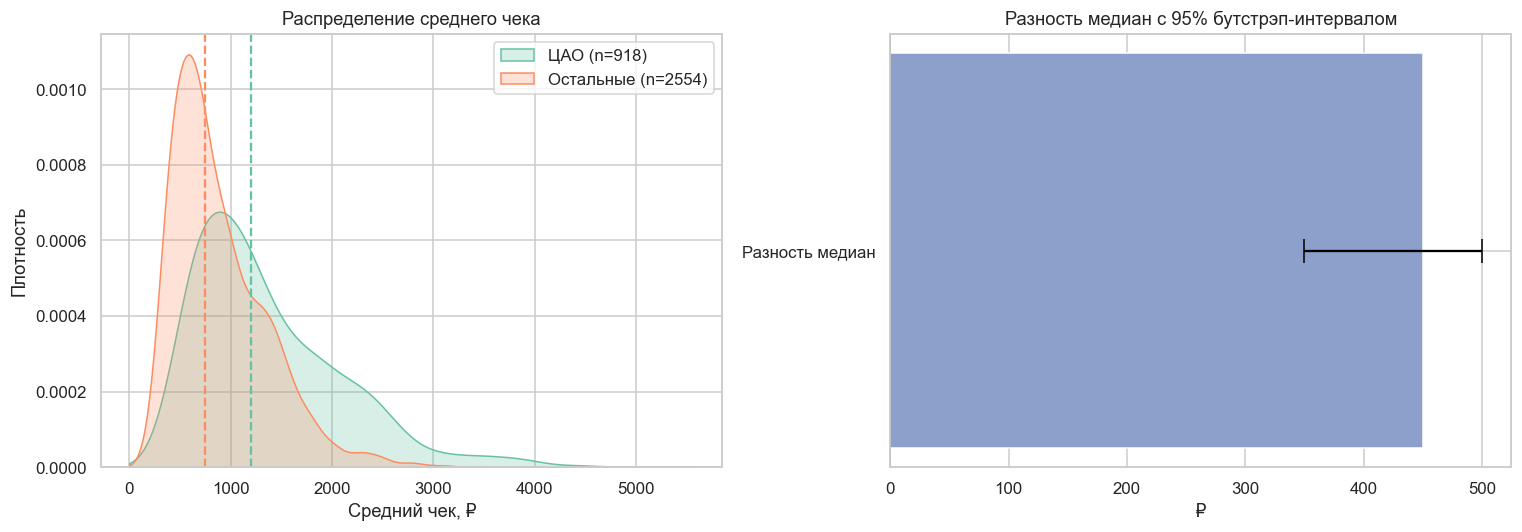

In [4]:
center = df.loc[df['is_center'], 'middle_avg_bill'].dropna()
rest = df.loc[~df['is_center'], 'middle_avg_bill'].dropna()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(center, ax=ax[0], fill=True, label=f'ЦАО (n={len(center)})', clip=(0, 6000))
sns.kdeplot(rest, ax=ax[0], fill=True, label=f'Остальные (n={len(rest)})', clip=(0, 6000))
ax[0].axvline(center.median(), ls='--', c='C0')
ax[0].axvline(rest.median(), ls='--', c='C1')
ax[0].set(title='Распределение среднего чека', xlabel='Средний чек, ₽', ylabel='Плотность')
ax[0].legend()

lo, hi = res['95% ДИ разности']
ax[1].barh(['Разность медиан'], [res['разность медиан']],
           xerr=[[res['разность медиан'] - lo], [hi - res['разность медиан']]],
           color='C2', height=.4, capsize=8)
ax[1].axvline(0, c='k', lw=1)
ax[1].set(title='Разность медиан с 95% бутстрэп-интервалом', xlabel='₽')
plt.tight_layout()
plt.show()

**Читаем результат.** Интервал не накрывает ноль — разница устойчива, а не
артефакт выборки. Размер эффекта (rank-biserial r) показывает, насколько
разделены распределения: значение около 0.3–0.5 означает средний эффект —
округа различаются заметно, но распределения сильно перекрываются, и
«дорогие» заведения есть за пределами центра.

## Гипотеза 2. Рейтинг по категориям

H0: медианный рейтинг одинаков во всех восьми категориях. Общий критерий
Краскела—Уоллиса скажет только «где-то есть различие»; чтобы понять, между
какими именно категориями, нужны попарные сравнения — с поправкой на
множественность, иначе при 28 парах ложное срабатывание почти гарантировано.

In [5]:
res2 = ST.test_rating_by_category(df)
for k, v in res2.items():
    print(f'{k:>24}: {v}')

                гипотеза: рейтинг одинаков во всех категориях
                критерий: Краскела—Уоллиса
                 k групп: 8
                       n: 8406
                       H: 193.0
                 p-value: 3.473898841430071e-38
  размер эффекта (eps^2): 0.0221
            сила эффекта: малый
                   вывод: H0 отвергается


In [6]:
pw = ST.pairwise_rating(df)
display(pw.head(15))
print(f'\nЗначимых пар после поправки Холма: {int(pw["значимо"].sum())} из {len(pw)}')
print(f'Было бы значимо без поправки: {int((pw["p-value"] < 0.05).sum())}')

,категория A,категория B,медиана A,медиана B,p-value,r,сила эффекта,p_holm,значимо
0,"бар, паб",кафе,4.3,4.1,2.607095e-26,0.254,малый,7.299867e-25,True
1,"бар, паб",быстрое питание,4.3,4.1,1.262592e-24,0.321,средний,3.409000e-23,True
2,быстрое питание,ресторан,4.1,4.2,6.033532e-13,-0.192,малый,1.568718e-11,True
3,кафе,ресторан,4.1,4.2,1.018502e-12,-0.124,малый,2.546254e-11,True
4,быстрое питание,пиццерия,4.1,4.2,7.202420e-12,-0.224,малый,1.728581e-10,True
5,булочная,быстрое питание,4.3,4.1,1.609863e-10,0.275,малый,3.702685e-09,True
6,"бар, паб",кофейня,4.3,4.2,5.102441e-10,0.161,малый,1.122537e-08,True
7,быстрое питание,кофейня,4.1,4.2,6.153547e-10,-0.173,малый,1.292245e-08,True
8,кафе,пиццерия,4.1,4.2,4.561610e-09,-0.151,малый,9.123220e-08,True
9,"бар, паб",ресторан,4.3,4.2,1.668279e-08,0.138,малый,3.169730e-07,True



Значимых пар после поправки Холма: 15 из 28
Было бы значимо без поправки: 20


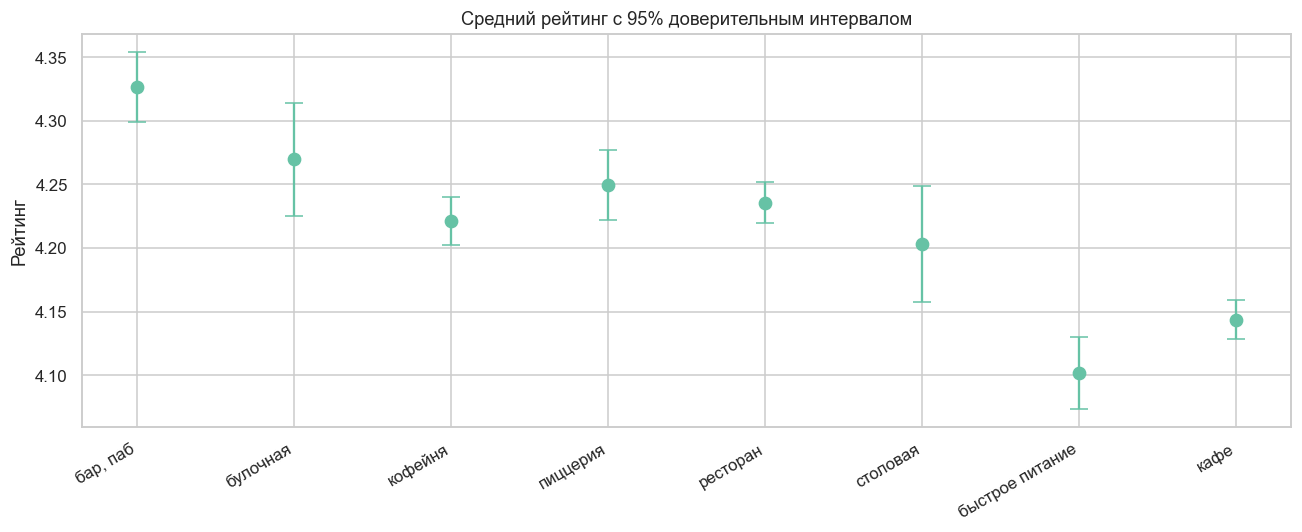

,count,mean,median,std
category,,,,
"бар, паб",764,4.326,4.3,0.390
булочная,256,4.270,4.3,0.364
кофейня,1413,4.221,4.2,0.363
пиццерия,633,4.249,4.2,0.351
ресторан,2042,4.236,4.2,0.375
столовая,315,4.203,4.2,0.410
быстрое питание,603,4.101,4.1,0.363
кафе,2380,4.144,4.1,0.388


In [7]:
order = df.groupby('category')['rating'].median().sort_values(ascending=False).index
stats_tbl = df.groupby('category')['rating'].agg(['count', 'mean', 'median', 'std'])
ci = {c: ST.bootstrap_ci(g['rating'], func=np.mean) for c, g in df.groupby('category')}

fig, ax = plt.subplots(figsize=(12, 5))
means = stats_tbl.loc[order, 'mean']
lo = [means[c] - ci[c][0] for c in order]
hi = [ci[c][1] - means[c] for c in order]
ax.errorbar(range(len(order)), means, yerr=[lo, hi], fmt='o', capsize=6, ms=8)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=30, ha='right')
ax.set(title='Средний рейтинг с 95% доверительным интервалом',
       ylabel='Рейтинг')
plt.tight_layout()
plt.show()

display(stats_tbl.loc[order].round(3))

**Читаем результат.** eps² — доля дисперсии рангов, объяснённая категорией.
Значение около 0.01–0.03 означает: категория объясняет считанные проценты
разброса рейтинга. Различия реальны, но для инвестиционного решения
бесполезны — выбирать формат по ожидаемому рейтингу нельзя.

## Гипотеза 3. Сетевость и категория

In [8]:
res3 = ST.test_chain_vs_category(df)
for k, v in res3.items():
    print(f'{k:>28}: {v}')

table = pd.crosstab(df['category'], df['chain_type'], normalize='index').mul(100).round(1)
display(table.sort_values('Сетевые', ascending=False))

                    гипотеза: сетевость не зависит от категории
                    критерий: хи-квадрат Пирсона
                        chi2: 359.9
                          df: 7
                     p-value: 9.135863322002097e-74
  размер эффекта (V Крамера): 0.207
                сила эффекта: малый
                       вывод: H0 отвергается


chain_type,Несетевые,Сетевые
category,,
булочная,32.4,67.6
пиццерия,46.3,53.7
кофейня,51.1,48.9
быстрое питание,51.2,48.8
кафе,66.3,33.7
ресторан,66.3,33.7
столовая,72.4,27.6
"бар, паб",74.9,25.1


## Гипотеза 4. Рейтинг и средний чек

                гипотеза: рейтинг не связан со средним чеком
                критерий: ранговая корреляция Спирмена
                       n: 3472
                     rho: 0.081
                 p-value: 1.5655631369319596e-06
            сила эффекта: пренебрежимо мал
                   вывод: H0 отвергается


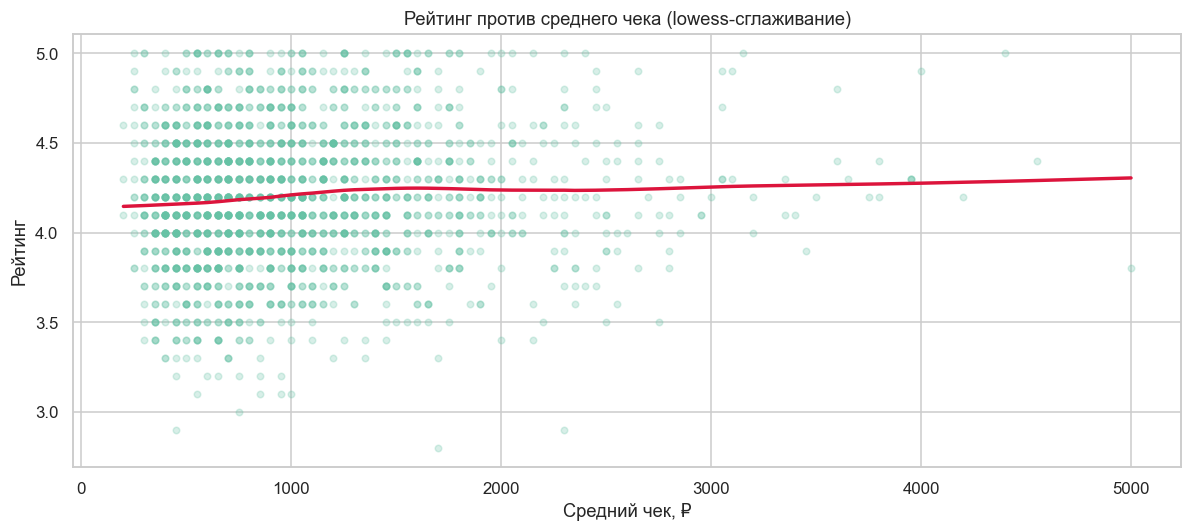

In [9]:
res4 = ST.test_rating_vs_bill(df)
for k, v in res4.items():
    print(f'{k:>24}: {v}')

sub = df[['rating', 'middle_avg_bill']].dropna()
fig, ax = plt.subplots(figsize=(11, 5))
sns.regplot(data=sub.sample(min(2000, len(sub)), random_state=1),
            x='middle_avg_bill', y='rating', lowess=True,
            scatter_kws=dict(alpha=.25, s=18), line_kws=dict(color='crimson'), ax=ax)
ax.set(title='Рейтинг против среднего чека (lowess-сглаживание)',
       xlabel='Средний чек, ₽', ylabel='Рейтинг')
plt.tight_layout()
plt.show()

## Итог

Ключевая поправка к выводам основного исследования: **статистическая значимость
здесь почти везде достигается за счёт размера выборки, а не за счёт величины
эффекта.** Практически значима только разница в чеке между центром и
периферией. Различия рейтингов между категориями значимы формально, но
объясняют считанные проценты разброса — строить на них решение нельзя.

Отсюда следует и постановка задачи для следующего ноутбука: раз рейтинг
предсказать по доступным признакам нельзя, выбирать локацию нужно по тому,
что измеримо — насыщенность ниши, потенциал выручки и структура конкуренции.

→ **[02 · Скоринг локаций](02_Скоринг_локаций.ipynb)**